# Stain normalization: picking reference patch(es)

We want a **reference** patch (or a few) that:
- Have **enough tissue** so Macenko can estimate stain vectors (no degenerate matrix).
- Are **representative** (typical H&E, not pale/dark outliers).

**Approach:** Apply **stricter** quality filters; require **tissue % final ≥ 0.5**. Pick a reference with **balanced H&E** (62nd % R, 38th % B) so Macenko gives both pink and purple. Fit Macenko and validate; optionally save reference index.

In [66]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, _), _, _ = load_data(data_dir=DATA_DIR)
print("Loaded train:", train_x.shape)

Loaded train: (262144, 96, 96, 3)


## 1. Quality helpers and metrics (same logic as tissue investigation)

We compute tissue % (saturation OR local variance, Otsu on edge cases), solid-color flag, and black ratio. For **reference candidates** we use a **stricter** minimum tissue: only patches with tissue % final **≥ 0.5** (exclude more than the 0.35 removal threshold).

In [67]:
def otsu_threshold_01(gray):
    flat = np.asarray(gray).ravel().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 1))
    bin_centers = (np.arange(256) + 0.5) / 256.0
    total = hist.sum()
    if total == 0: return 0.5
    p = hist / total
    sigma_b_sq_max, best_t = -1.0, 0.5
    for t in range(1, 255):
        w0, w1 = p[:t].sum(), p[t:].sum()
        if w0 == 0 or w1 == 0: continue
        mu0 = (p[:t] * bin_centers[:t]).sum() / w0
        mu1 = (p[t:] * bin_centers[t:]).sum() / w1
        sigma_b_sq = w0 * w1 * (mu0 - mu1) ** 2
        if sigma_b_sq > sigma_b_sq_max:
            sigma_b_sq_max, best_t = sigma_b_sq, bin_centers[t]
    return best_t

def saturation_from_rgb(rgb):
    mx, mn = rgb.max(axis=2), rgb.min(axis=2)
    return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)

def local_variance_map(gray, win=11):
    m = uniform_filter(gray.astype(np.float64), size=win, mode='nearest')
    m2 = uniform_filter((gray.astype(np.float64))**2, size=win, mode='nearest')
    return m2 - m**2

def tissue_pct_otsu_normalized(gray):
    p5, p95 = np.percentile(gray, 5), np.percentile(gray, 95)
    span = max(p95 - p5, 1e-8)
    g = np.clip((gray - p5) / span, 0, 1)
    t = otsu_threshold_01(g)
    return float(np.sum(g < t) / g.size)

SAT_THRESHOLD = 0.12
VAR_THRESHOLD = 0.003
EDGE_LO, EDGE_HI = 0.12, 0.45
SOLID_COLOR_STD_THRESHOLD = 0.04
HIGH_BLACK_THRESHOLD = 0.5
# Stricter: only patches with plenty of tissue are reference candidates
REFERENCE_MIN_TISSUE = 0.5
LOCAL_VAR_WIN = 11

print("Reference candidates: tissue % final >= ", REFERENCE_MIN_TISSUE, ", not solid-color, not high black")

Reference candidates: tissue % final >=  0.5 , not solid-color, not high black


In [68]:
# Sample patches and compute metrics (same as tissue notebook)
n_sample = min(30000, len(train_x))
np.random.seed(42)
indices = np.random.choice(len(train_x), size=n_sample, replace=False)

rows = []
for i in indices:
    patch = np.asarray(train_x[i]).astype(np.float64)
    if patch.max() > 1.0: patch = patch / 255.0
    patch = np.clip(patch, 0, 1)
    gray = patch.mean(axis=2)
    n_px = gray.size
    n_elems = patch.size
    ratio_black = float(np.sum(patch <= 0.1) / n_elems)
    gray_std = float(np.std(gray))
    sat = saturation_from_rgb(patch)
    tissue_pct_sat = float(np.sum(sat > SAT_THRESHOLD) / n_px)
    var_map = local_variance_map(gray, win=LOCAL_VAR_WIN)
    tissue_pct_var = float(np.sum(var_map > VAR_THRESHOLD) / n_px)
    tissue_pct_combined = float(np.sum((sat > SAT_THRESHOLD) | (var_map > VAR_THRESHOLD)) / n_px)
    if EDGE_LO < tissue_pct_combined < EDGE_HI:
        otsu_norm = tissue_pct_otsu_normalized(gray)
        tissue_pct_final = max(tissue_pct_combined, otsu_norm)
    else:
        tissue_pct_final = tissue_pct_combined
    mean_rgb = patch.reshape(-1, 3).mean(axis=0)
    solid_color = 1 if gray_std < SOLID_COLOR_STD_THRESHOLD else 0
    blue_dom_pct = float((patch[:,:,2] > patch[:,:,0]).mean())  # B > R (for Macenko vs Reinhard rule)
    rows.append((i, ratio_black, gray_std, tissue_pct_final, solid_color, mean_rgb[0], mean_rgb[1], mean_rgb[2], blue_dom_pct))

data = np.array(rows)
idx_col = 0
b_col, std_col, tissue_col, solid_col = 1, 2, 3, 4
r_col, g_col, b_mean_col = 5, 6, 7
blue_dom_col = 8

solid_mask = data[:, solid_col] == 1
high_black_mask = data[:, b_col] >= HIGH_BLACK_THRESHOLD
high_tissue_mask = data[:, tissue_col] >= REFERENCE_MIN_TISSUE
candidate_mask = ~solid_mask & ~high_black_mask & high_tissue_mask
candidates = data[candidate_mask]

print("Sampled", n_sample, "patches")
print("Solid-color:", solid_mask.sum(), "| High black:", high_black_mask.sum(), "| Tissue >= ", REFERENCE_MIN_TISSUE, ":", high_tissue_mask.sum())
print("Reference candidates (not solid, not high black, tissue >= " + str(REFERENCE_MIN_TISSUE) + "):", len(candidates))

C:\Users\tamer\AppData\Local\Temp\ipykernel_16788\3842474581.py:21: RuntimeWarning: invalid value encountered in divide
  return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)


Sampled 30000 patches
Solid-color: 235 | High black: 3 | Tissue >=  0.5 : 27399
Reference candidates (not solid, not high black, tissue >= 0.5): 27376


## 2. Pick reference: balanced H&E (tissue + mild pink bias)

Among candidates, pick the one **closest to** (median tissue %, **62nd % R**, median G, **38th % B**), with R and B weighted more so the reference has a bit more pink and normalized images are less purple.

In [69]:
if len(candidates) == 0:
    raise RuntimeError("No reference candidates. Lower REFERENCE_MIN_TISSUE or increase n_sample.")

med_tissue = np.median(candidates[:, tissue_col])
med_g = np.median(candidates[:, g_col])
# Nudge toward pink so normalized images aren't too purple
target_r = np.percentile(candidates[:, r_col], 62)
target_b = np.percentile(candidates[:, b_mean_col], 38)
target = np.array([med_tissue, target_r, med_g, target_b])
feats = candidates[:, [tissue_col, r_col, g_col, b_mean_col]]
# Weight R and B more so the chosen reference actually matches the 58th % R / 42nd % B criteria
weights = np.array([1.0, 2.5, 1.0, 2.5])  # [tissue, R, G, B] - emphasize R and B
dists = np.sum(weights * (feats - target) ** 2, axis=1)
best_idx_in_candidates = np.argmin(dists)
ref_train_idx = int(candidates[best_idx_in_candidates, idx_col])

print("Target (tissue, R, G, B):", round(med_tissue, 3), round(target_r, 3), round(med_g, 3), round(target_b, 3))
print("Chosen reference: train index", ref_train_idx,
      "| tissue % =", round(candidates[best_idx_in_candidates, tissue_col], 3),
      "| mean R =", round(candidates[best_idx_in_candidates, r_col], 3), "| mean B =", round(candidates[best_idx_in_candidates, b_mean_col], 3))
# Temporary: use a fixed reference (comment out next line to use computed reference)
ref_train_idx = 76889
print("Overriding to fixed reference: train index", ref_train_idx)

Target (tissue, R, G, B): 1.0 0.727 0.484 0.644
Chosen reference: train index 104772 | tissue % = 1.0 | mean R = 0.732 | mean B = 0.639
Overriding to fixed reference: train index 76889


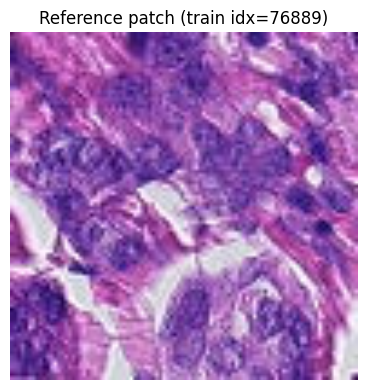

In [70]:
# Show reference patch
ref_patch = np.asarray(train_x[ref_train_idx])
if ref_patch.max() <= 1.0: ref_patch = np.clip(ref_patch, 0, 1)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(ref_patch, interpolation='bilinear')
ax.set_title(f"Reference patch (train idx={ref_train_idx})")
ax.axis("off")
plt.tight_layout()
plt.show()
# Note: PCam patches are 96x96; interpolation='bilinear' smooths the display. For 1:1 pixels use interpolation='nearest' and figsize=(2, 2).


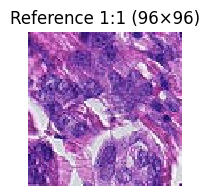

In [71]:
plt.figure(figsize=(2, 2))
plt.imshow(ref_patch, interpolation='nearest')
plt.axis('off')
plt.title('Reference 1:1 (96×96)')
plt.show()

## 3. Fit Macenko on reference and validate

Requires `staintools` and `spams` (use `pip install staintools spams-bin` on Windows). Restart the kernel after installing.

In [72]:
try:
    from staintools import StainNormalizer
    STAINTOOLS_AVAILABLE = True
except ImportError as e:
    STAINTOOLS_AVAILABLE = False
    print("StainTools import failed:", e)
    print('If the error is No module named "spams", run: pip install spams-bin (Windows)')
    print('Then restart the kernel and run this cell again.')

if STAINTOOLS_AVAILABLE:
    ref_uint8 = (np.clip(ref_patch, 0, 1) * 255).astype(np.uint8) if ref_patch.max() <= 1.0 else np.clip(ref_patch, 0, 255).astype(np.uint8)
    try:
        from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer
        ref_uint8 = LuminosityStandardizer.standardize(ref_uint8)
    except Exception as e_std:
        print("Luminosity standardizer skipped:", e_std)
    try:
        normalizer = StainNormalizer(method='macenko')
        normalizer.fit(ref_uint8)
        print("Macenko fitted successfully on reference patch.")
    except Exception as e:
        print("Macenko fit failed:", e)
        normalizer = None
else:
    normalizer = None

Macenko fitted successfully on reference patch.


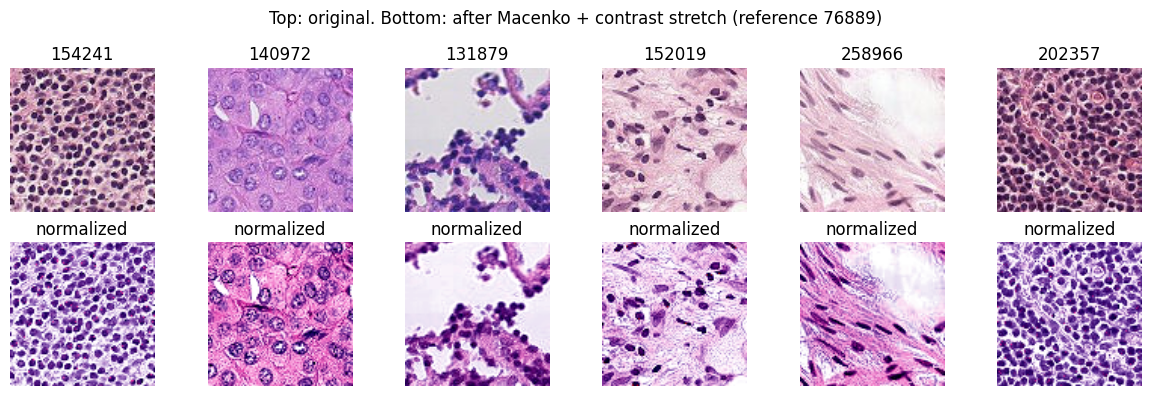

In [73]:
# Optional: apply to a few other patches and show before/after
# Why do some patches go completely purple after Macenko? The normalizer only *rebalances* the
# H and E already present. If a source patch has very little eosin (pink)—e.g. dense nuclei,
# pale staining, or mostly hematoxylin—there is almost no pink to scale up, so the result stays purple.
# Patches that look good (140972, 131879, 258966) have both stains; ones that go full purple (202357, 154241) don't.
# Luminosity standardization before transform helps keep H&E balance.
# Contrast stretch after normalization restores visible contrast (normalized images often look pale).
def contrast_stretch_uint8(img, p_low=2, p_high=98):
    """Stretch pixel values so p_low and p_high percentiles map to 0 and 255. Returns uint8."""
    lo, hi = np.percentile(img, (p_low, p_high))
    if hi <= lo:
        return img
    out = (np.clip(img.astype(np.float32), lo, hi) - lo) / (hi - lo) * 255
    return out.astype(np.uint8)
if normalizer is not None:
    n_show = 6
    other_indices = [int(candidates[i, idx_col]) for i in range(len(candidates)) if int(candidates[i, idx_col]) != ref_train_idx][:n_show]
    fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))
    for j, idx in enumerate(other_indices[:n_show]):
        p = np.asarray(train_x[idx])
        if p.max() <= 1.0: p = (np.clip(p, 0, 1) * 255).astype(np.uint8)
        else: p = np.clip(p, 0, 255).astype(np.uint8)
        axes[0, j].imshow(p, interpolation='bilinear')
        axes[0, j].set_title(str(idx))
        axes[0, j].axis("off")
        try:
            try:
                from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer
                p = LuminosityStandardizer.standardize(p.copy())
            except Exception:
                pass
            p_norm = normalizer.transform(p)
            p_norm = contrast_stretch_uint8(p_norm)
            axes[1, j].imshow(p_norm, interpolation='bilinear')
        except Exception as e:
            axes[1, j].text(0.5, 0.5, "fail", ha='center', va='center')
        axes[1, j].set_title("normalized")
        axes[1, j].axis("off")
    plt.suptitle("Top: original. Bottom: after Macenko + contrast stretch (reference " + str(ref_train_idx) + ")")
    plt.tight_layout()
    plt.show()

## 4. Macenko vs Reinhard: decision rule

**Rule:** Patches with **low blue_dom_pct** (few pixels with B &gt; R) go purple with Macenko; use **Reinhard** for those. Otherwise use **Macenko**. Threshold: below 25th percentile of blue_dom_pct in the sample → Reinhard. Same reference for both.

Of 30000 sampled patches, 10243 are flagged as H-heavy (mean R < mean B) -> would send to Reinhard


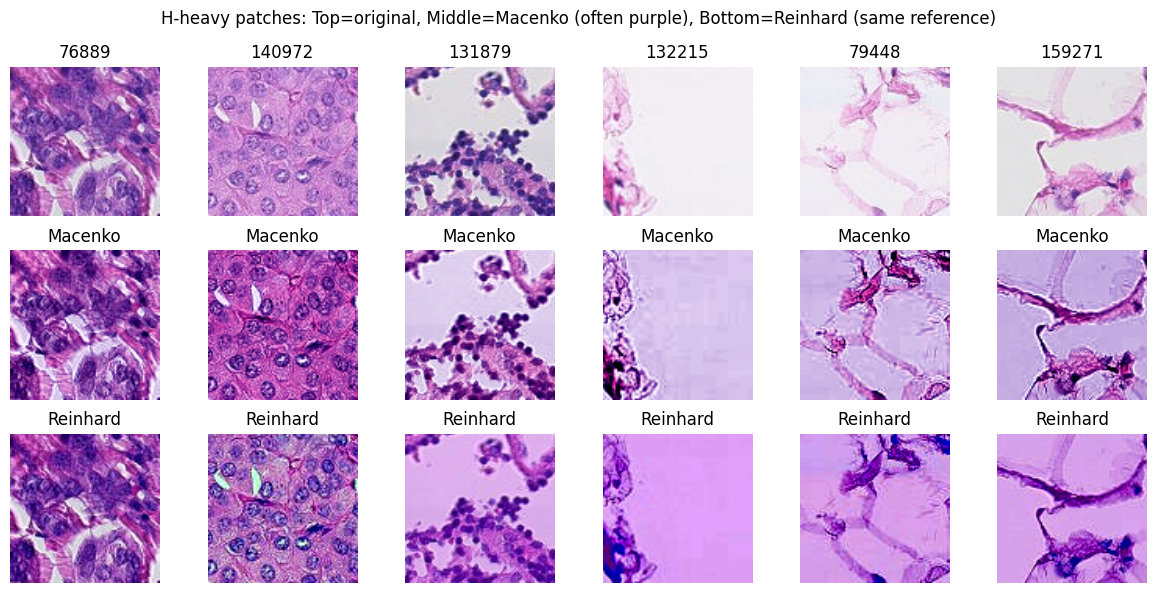

In [74]:
# Rule: blue_dom_pct < threshold -> Reinhard (else Macenko). Threshold = 25th percentile of sample.
REINHARD_PERCENTILE = 25
blue_dom_threshold = np.percentile(data[:, blue_dom_col], REINHARD_PERCENTILE)
to_reinhard = data[:, blue_dom_col] < blue_dom_threshold
n_reinhard = int(to_reinhard.sum())
n_macenko = len(data) - n_reinhard
print(f"blue_dom_pct threshold (p{REINHARD_PERCENTILE}): {blue_dom_threshold:.4f}")
print(f"Of {len(data)} sampled patches: {n_reinhard} -> Reinhard, {n_macenko} -> Macenko")

# Fit Reinhard on same reference
ref_uint8 = (np.clip(ref_patch, 0, 1) * 255).astype(np.uint8) if ref_patch.max() <= 1.0 else np.clip(ref_patch, 0, 255).astype(np.uint8)
try:
    from staintools import ReinhardColorNormalizer
    reinhard_norm = ReinhardColorNormalizer()
    reinhard_norm.fit(ref_uint8)
except Exception as e:
    print("Reinhard fit failed:", e)

# Show the two problematic patches (154241, 202357): Original / Macenko / Reinhard
bad_idx = [154241, 202357]
fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for j, idx in enumerate(bad_idx):
    p = np.asarray(train_x[idx])
    p_uint8 = (np.clip(p, 0, 1) * 255).astype(np.uint8) if p.max() <= 1.0 else np.clip(p, 0, 255).astype(np.uint8)
    axes[0, j].imshow(p_uint8, interpolation='bilinear')
    axes[0, j].set_title(f"Original {idx}")
    axes[0, j].axis("off")
    try:
        p_mac = normalizer.transform(p_uint8.copy())
        axes[1, j].imshow(contrast_stretch_uint8(p_mac), interpolation='bilinear')
    except Exception:
        axes[1, j].text(0.5, 0.5, "Macenko fail", ha='center', va='center')
    axes[1, j].set_title("Macenko")
    axes[1, j].axis("off")
    try:
        p_rein = reinhard_norm.transform(p_uint8.copy())
        axes[2, j].imshow(contrast_stretch_uint8(p_rein), interpolation='bilinear')
    except Exception:
        axes[2, j].text(0.5, 0.5, "Reinhard fail", ha='center', va='center')
    axes[2, j].set_title("Reinhard")
    axes[2, j].axis("off")
plt.suptitle("Low blue_dom_pct patches: Original vs Macenko (purple) vs Reinhard (same reference)")
plt.tight_layout()
plt.show()

## 5. (Optional) How the rule was chosen

Comparing patches **154241, 202357** (go purple with Macenko) vs **140972, 131879, 258966** (work well), **blue_dom_pct** (fraction of pixels with B &gt; R) was the strongest separator: low blue_dom_pct → use Reinhard. Section 4 applies this as a percentile threshold on the sample.

In [76]:
# Decision rule from quantitative comparison: blue_dom_pct was strongest separator (low in bad patches).
print("Rule: blue_dom_pct < threshold -> Reinhard; else Macenko. Threshold and counts in Section 4.")

Metrics for bad (154241, 202357) vs good (140972, 131879, 258966):
   idx label   mean_r   mean_g   mean_b  tissue_pct  dark_pct  blue_dom_pct  nuclei_like_pct  low_lum_pct  p25_gray  p75_gray  H_proxy_std
154241   bad 0.638067 0.493928 0.604771    1.000000  0.293728      0.247504         0.187717     0.279731  0.355556  0.792157     0.266354
202357   bad 0.579020 0.391393 0.530526    1.000000  0.391927      0.177951         0.153863     0.379991  0.298039  0.688889     0.242408
140972  good 0.744450 0.510500 0.798290    1.000000  0.015951      0.902452         0.035156     0.026693  0.614379  0.762092     0.128117
131879  good 0.702529 0.616070 0.764154    0.767578  0.148763      0.843641         0.184896     0.164280  0.524183  0.865359     0.269543
258966  good 0.896175 0.807419 0.853975    0.744249  0.008247      0.052951         0.000434     0.006076  0.801307  0.949020     0.151216

--- What stands out (bad vs good, mean difference) ---
  mean_r: bad=0.6085  good=0.7811  diff=-0.

## 4. Save reference index for pipeline

Save the chosen train index (and options) so the preprocessing pipeline or training can use the same reference.

In [75]:
out_dir = os.path.join(PROJECT_ROOT, "experiments", "stain_reference")
os.makedirs(out_dir, exist_ok=True)

stain_ref = {
    "reference_train_index": ref_train_idx,
    "REFERENCE_MIN_TISSUE": REFERENCE_MIN_TISSUE,
    "n_candidates": len(candidates),
    "n_sample": n_sample,
}
path = os.path.join(out_dir, "stain_reference.json")
with open(path, "w") as f:
    json.dump(stain_ref, f, indent=2)
print("Saved", path)
print(json.dumps(stain_ref, indent=2))

Saved c:\GP_ECG\experiments\stain_reference\stain_reference.json
{
  "reference_train_index": 76889,
  "REFERENCE_MIN_TISSUE": 0.5,
  "n_candidates": 27376,
  "n_sample": 30000
}


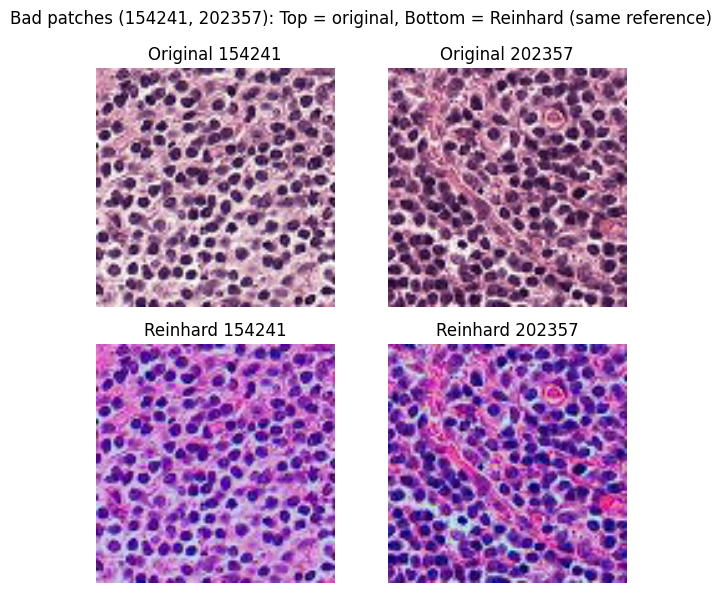

In [77]:
# Bad patches (154241, 202357) Original / Macenko / Reinhard are shown in Section 4.